# DE-Har 2025 drought-cascade — poster figures

Single-notebook build for the 2-figure poster:
1. **Figure 1** — multi-panel time series of the full 2025 campaign, with shaded meteorological-stress window. Two layout variants (10-panel + 8-panel) produced side by side.
2. **Figure 2** — response-horizon figure showing when each stream first responds and recovers relative to the tree-stress event (SWP < −1.5 MPa ± 21 d buffer). Dual-method changepoint detection: `ruptures.Dynp` for daily streams, first-2σ-departure rule for sparse satellite streams.

All timestamps are kept **UTC-aware** end-to-end. Predawn windows are computed dynamically from site radiation.

In [1]:
# Imports ────────────────────────────────────────────────────────────────────
from __future__ import annotations
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import spyndex
import ruptures as rpt

# Config ────────────────────────────────────────────────────────────────────
TARGET_YEAR       = 2025
TOWER_X, TOWER_Y  = 395509.71, 5309956.22          # EPSG:32632 (UTM 32N)
ROI_RADIUS_M      = 100.0                           # satellite ROI

# Satellite processing
S1_ORBIT          = "ascending"                     # "ascending" | "descending"
RH_THRESH_PCT     = 95.0                            # drop S1 scenes with RH > thresh at acquisition
S1_RAIN_THRESH_MM = 1.0                             # drop S1 scenes with >1 mm in 12 h prior
S1_THETA_REF      = 40.0                            # cosine-θ normalisation reference
S1_N              = 2                               # cos-θ exponent (vegetation: 2)
S1_SMOOTH_WINDOW  = 2                               # rolling median over ~3 revisits

# Changepoint / stress
SWP_STRESS_MPA     = -1.5                           # physiological stress threshold
ZOOM_BUFFER_DAYS   = 21                             # default zoom buffer
BUFFER_SWEEP_DAYS  = (14, 21, 30)                   # sensitivity sweep for dense streams
BASELINE_DAYS_PRE  = (30, 7)                        # [stress_start-30d, stress_start-7d] for dense
BASELINE_DAYS_PRE_SPARSE = (90, 7)                  # wider window for sparse streams (S1/S2/TLS)
DROP_BASELINE_MIN_SPARSE = 3                        # sparse streams need fewer baseline obs
SIGMA_THRESH       = 2.0                            # sparse-stream departure threshold
SIGMA_RECOVER      = 1.0                            # sparse-stream recovery threshold
DROP_NOBS_MIN      = 4                              # drop streams with fewer obs in zoom
DROP_BASELINE_MIN  = 5                              # drop streams with fewer obs in baseline
DROP_GAPFRAC_MAX   = 0.10                           # drop dense streams with > 10% gaps

# Leaf angle / PAI
LEAF_ANGLE_WINDOW_UTC = (11, 15)                    # daytime window (UTC hours)
LEAF_PRECIP_THR_MM    = 0.0001                      # precip trigger for leaf quality mask
LEAF_PRECIP_LOCKOUT_H = 12.0                        # lockout hours after wet step
UNDERSTORY_MAX_M      = 10.0                        # PAI split height

# Tree / camera assignments (h10546 is the SWP + cam65/66/67 tree)
SWP_TREE           = "h10546"
LEAF_CAMS          = ["cam65", "cam66", "cam67"]    # for h10546

# Meteorological stress thresholds
DRY_RUN_MIN_DAYS   = 10                             # consecutive dry days
DRY_PRECIP_MAX_MM  = 0.5                            # a day is "dry" below this
VPD_HIGH_HPA       = 15.0                           # daily-max VPD threshold for stress
SM_LOW_PCT         = 20.0                           # root-zone SM threshold for stress

# Sentinel-2: manually-curated clear-sky dates for 2025
S2_MANUAL_DATES_2025 = [
    "2025-01-13","2025-02-27","2025-03-04","2025-03-09","2025-03-19",
    "2025-04-03","2025-04-08","2025-04-10","2025-04-28","2025-04-30",
    "2025-05-10","2025-05-20","2025-05-30","2025-06-09","2025-06-12",
    "2025-06-17","2025-06-19","2025-06-22","2025-06-29","2025-07-02",
    "2025-08-08","2025-08-11","2025-08-18","2025-08-26","2025-08-31",
    "2025-09-20","2025-10-07","2025-10-15","2025-10-30","2025-11-04",
    "2025-11-06","2025-11-19","2025-12-09",
]
S2_INDICES = ["NDVI", "kNDVI", "EVI", "NIRv", "SAVI", "CIRE", "MTCI", "NDII"]
S1_LINEAR_VARS = ["VV_lin", "VH_lin", "SPAN_lin", "CR_lin", "RVI"]

# Paths ─────────────────────────────────────────────────────────────────────
ROOT_DIR = Path.cwd().parents[2]                    # notebooks/02_analysis/poster/ → project root
DATA_DIR = ROOT_DIR / "data"
FIG_DIR  = ROOT_DIR / "figures" / "poster"
FIG_DIR.mkdir(parents=True, exist_ok=True)

P = {
    "meteo":   DATA_DIR / "processed/atmosphere_soil/meteo_dehar_30min.csv",
    "fluxes":  DATA_DIR / "processed/atmosphere_soil/fluxes_dehar_30min.csv",
    "sm":      DATA_DIR / "processed/atmosphere_soil/soil_moisture_dehar_30min.csv",
    "precip":  DATA_DIR / "processed/atmosphere_soil/HARTHM_2025_Precipitation_30min_UTC.csv",
    "sapflow": DATA_DIR / "processed/physiology/sap_flux_density/sapflow_dehar_30min.csv",
    "swp":     DATA_DIR / "processed/physiology/stemwater_potential/swp_dehar_15min.csv",
    "twd":     DATA_DIR / "processed/physiology/twd/twd_dehar_30min.csv",
    "vod":     DATA_DIR / "processed/proximal_rs/gnss_vod/gnss_vod_dehar_30min.csv",
    "leaf_angle": DATA_DIR / "processed/proximal_rs/anglecam/leaf_angle_cam65_66_67_native.csv",
    "pai":     DATA_DIR / "processed/proximal_rs/leaf/leaf_hemi_hi_2025_scan05utc.csv",
    "s1_dir":  DATA_DIR / "processed/satellite/sentinel1",
    "s2_dir":  DATA_DIR / "processed/satellite/sentinel2",
}

# Paul Tol palettes (colour-blind-safe) ─────────────────────────────────────
TOL_BRIGHT = {
    "blue":   "#4477AA", "red":    "#EE6677", "green":  "#228833",
    "yellow": "#CCBB44", "cyan":   "#66CCEE", "purple": "#AA3377",
    "grey":   "#BBBBBB", "black":  "#000000",
}
TOL_LIGHT = {
    "lblue":  "#77AADD", "lcyan":  "#99DDFF", "lmint":  "#44BB99",
    "lpear":  "#BBCC33", "lolive": "#AAAA00", "lyellow":"#EEDD88",
    "lorange":"#EE8866", "lpink":  "#FFAABB", "lgrey":  "#DDDDDD",
}
# Domain colour mapping for Figure 2 Gantt chart
DOMAIN_COLOR = {
    "atmosphere":  TOL_BRIGHT["red"],
    "soil":        TOL_BRIGHT["yellow"],
    "physiology":  TOL_BRIGHT["green"],
    "proximal":    TOL_BRIGHT["cyan"],
    "satellite":   TOL_BRIGHT["purple"],
    "flux":        TOL_BRIGHT["blue"],
}

# Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="ticks", font_scale=1.0)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":  True,
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "figure.dpi": 110,
})

STRESS_SHADE_COLOR = "#E76F51"
print(f"Target year: {TARGET_YEAR}  |  Root: {ROOT_DIR}")

Target year: 2025  |  Root: /mnt/data/lk1167/projects/dehar-spac


## 1. Load 30-min / 15-min CSV streams

All files are UTC-aware. Helper keeps the index tz-aware (we never call `tz_localize(None)`).

In [2]:
def load_csv(path: Path, datetime_col: str = "datetime") -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=[datetime_col], index_col=datetime_col)
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    return df

# Load all streams ──────────────────────────────────────────────────────────
meteo   = load_csv(P["meteo"])
fluxes  = load_csv(P["fluxes"])
sm      = load_csv(P["sm"])
precip  = load_csv(P["precip"], datetime_col="From")[["Precipitation_Sum_mm"]]
precip.index.name = "datetime"
if precip.index.tz is None:
    precip.index = precip.index.tz_localize("UTC")
sapflow = load_csv(P["sapflow"])
swp_hr  = load_csv(P["swp"])
twd     = load_csv(P["twd"])
vod     = load_csv(P["vod"])

# Leaf angle (tz-aware UTC ISO strings in this file)
leaf_angle = pd.read_csv(P["leaf_angle"], parse_dates=["datetime"], index_col="datetime")
if leaf_angle.index.tz is None:
    leaf_angle.index = leaf_angle.index.tz_localize("UTC")

# PAI (long format: one row per (scan, height))
pai_long = pd.read_csv(P["pai"], parse_dates=["datetime"])
pai_long["datetime"] = pd.to_datetime(pai_long["datetime"], utc=True)

# Sanity print
for name, df in [("meteo",meteo),("fluxes",fluxes),("sm",sm),("precip",precip),
                 ("sapflow",sapflow),("swp_hr",swp_hr),("twd",twd),("vod",vod),
                 ("leaf_angle",leaf_angle)]:
    print(f"{name:12s} {df.index.min()} → {df.index.max()}  (n={len(df):,})")
print(f"pai_long     {pai_long['datetime'].min()} → {pai_long['datetime'].max()}  "
      f"(scans={pai_long['datetime'].nunique()})")

meteo        2024-11-30 23:30:00+00:00 → 2025-11-30 23:00:00+00:00  (n=17,520)
fluxes       2024-11-30 23:30:00+00:00 → 2025-11-30 23:00:00+00:00  (n=17,520)
sm           2024-11-30 23:30:00+00:00 → 2025-11-30 23:00:00+00:00  (n=17,520)
precip       2025-01-01 00:00:00+00:00 → 2025-12-31 23:30:00+00:00  (n=17,520)
sapflow      2025-01-01 00:00:00+00:00 → 2025-11-21 10:00:00+00:00  (n=15,576)
swp_hr       2025-05-05 23:15:00+00:00 → 2025-11-21 10:15:00+00:00  (n=19,148)
twd          2024-12-31 23:00:00+00:00 → 2025-11-21 10:00:00+00:00  (n=15,560)
vod          2025-04-17 14:30:00+00:00 → 2025-12-14 23:00:00+00:00  (n=9,480)
leaf_angle   2025-05-01 00:07:01+00:00 → 2025-09-16 00:29:46+00:00  (n=301,364)
pai_long     2025-04-17 05:10:28+00:00 → 2025-11-30 05:10:28+00:00  (scans=228)


## 2. Derived daily series

Each block builds one daily series + its uncertainty band. Output lives in the `daily` dict.

In [3]:
daily = {}

# Restrict all streams to 2025 for derivation (saves compute on multi-year files) ─
def _slice_year(df, year=TARGET_YEAR):
    return df[(df.index.year == year)]

meteo_y   = _slice_year(meteo)
fluxes_y  = _slice_year(fluxes)
sm_y      = _slice_year(sm)
precip_y  = _slice_year(precip)
sapflow_y = _slice_year(sapflow)
swp_y     = _slice_year(swp_hr)
twd_y     = _slice_year(twd)
vod_y     = _slice_year(vod)
la_y      = _slice_year(leaf_angle)
pai_long_y = pai_long[pai_long["datetime"].dt.year == TARGET_YEAR].copy()

# (i) Tair + VPD daily mean + max ────────────────────────────────────────────
daily["tair_mean"] = meteo_y["tair_c"].resample("1D").mean()
daily["tair_max"]  = meteo_y["tair_c"].resample("1D").max()
daily["tair_std"]  = meteo_y["tair_c"].resample("1D").std()
daily["vpd_mean"]  = meteo_y["vpd_hpa"].resample("1D").mean()
daily["vpd_max"]   = meteo_y["vpd_hpa"].resample("1D").max()
daily["vpd_std"]   = meteo_y["vpd_hpa"].resample("1D").std()

# (ii) Soil moisture: IQR guard across profiles, then profile-mean, then depth-mean
def _robust_profile_mean(df, depth_label):
    # For a given depth (e.g. '5cm'), average across profiles a/b/c with IQR guard.
    cols = [c for c in df.columns if c.startswith("vwc_pct_") and c.endswith(f"_{depth_label}")]
    if not cols:
        return None
    vals = df[cols]
    med  = vals.median(axis=1)
    iqr  = vals.quantile(0.75, axis=1) - vals.quantile(0.25, axis=1)
    # drop any profile whose value is >3*IQR from the median
    clipped = vals.where((vals.sub(med, axis=0).abs()).le(3 * iqr, axis=0) | iqr.isna().to_frame().values, np.nan)
    return clipped.mean(axis=1)

sm_5  = _robust_profile_mean(sm_y, "5cm")
sm_10 = _robust_profile_mean(sm_y, "10cm")
sm_20 = _robust_profile_mean(sm_y, "20cm")
# Depth matrix (30-min) → collapse across depths (mean + std)
sm_depth_mat = pd.concat([sm_5.rename("d5"), sm_10.rename("d10"), sm_20.rename("d20")], axis=1)
sm_root_zone = sm_depth_mat.mean(axis=1)
sm_root_std  = sm_depth_mat.std(axis=1)

daily["sm_mean"] = sm_root_zone.resample("1D").mean()
daily["sm_std"]  = sm_root_std.resample("1D").mean()    # mean cross-depth spread per day
daily["precip_mm"] = precip_y["Precipitation_Sum_mm"].resample("1D").sum()

# (iii) SWP predawn — dynamic sunrise (h10546 only) ─────────────────────────
def _sunrise_utc_hour(rg_series: pd.Series, thr_wm2: float = 5.0) -> pd.Series:
    df = rg_series.to_frame("rg")
    df["date"] = df.index.normalize()
    df = df[df["rg"] > thr_wm2]
    first_ts_per_day = df.groupby("date").apply(lambda g: g.index.min())
    # return fractional hour-of-day (UTC)
    return first_ts_per_day.dt.hour + first_ts_per_day.dt.minute / 60.0

sunrise_h = _sunrise_utc_hour(meteo_y["rg_wm2"])
swp_col   = swp_y[f"swp_mpa_{SWP_TREE}"].dropna()
predawn_records = []
for date, sr_h in sunrise_h.items():
    win_end   = pd.Timestamp(date).tz_convert("UTC") + pd.Timedelta(hours=float(sr_h)) \
                if pd.Timestamp(date).tzinfo else pd.Timestamp(date, tz="UTC") + pd.Timedelta(hours=float(sr_h))
    win_start = win_end - pd.Timedelta(hours=2)
    window    = swp_col.loc[win_start:win_end]
    if len(window):
        predawn_records.append({
            "date": date, "swp_mean": window.mean(),
            "swp_std": window.std(), "n": len(window),
        })
swp_pd = pd.DataFrame(predawn_records).set_index("date")
swp_pd.index = pd.DatetimeIndex(swp_pd.index, tz="UTC")
swp_pd["swp_ci95"] = 1.96 * swp_pd["swp_std"] / np.sqrt(swp_pd["n"])
daily["swp_pd"]      = swp_pd["swp_mean"]
daily["swp_pd_ci95"] = swp_pd["swp_ci95"]

# (iv) Sap flow — daily mean across trees + cross-tree std ──────────────────
sf_daily_per_tree = sapflow_y.resample("1D").mean()
daily["sapflow_mean"] = sf_daily_per_tree.mean(axis=1)
daily["sapflow_std"]  = sf_daily_per_tree.std(axis=1)

# (v) TWD — daily mean across trees + cross-tree std ───────────────────────
twd_daily_per_tree = twd_y.resample("1D").mean()
daily["twd_mean"] = twd_daily_per_tree.mean(axis=1)
daily["twd_std"]  = twd_daily_per_tree.std(axis=1)

# (vi) GNSS VOD — predawn across receivers (1–5 UTC median) ─────────────────
vod_pd = vod_y.between_time("01:00", "04:59").resample("1D").median()
daily["vod_pd_mean"] = vod_pd.mean(axis=1)
daily["vod_pd_std"]  = vod_pd.std(axis=1)

# (vii) Leaf angle — h10546, mean across cam65/66/67, daytime UTC window ────
def _build_leaf_quality_mask(la_idx, meteo_df, precip_df,
                             precip_thr=LEAF_PRECIP_THR_MM, lockout_h=LEAF_PRECIP_LOCKOUT_H):
    mask = pd.Series(True, index=la_idx)
    if "Precipitation_Sum_mm" in precip_df.columns:
        p = precip_df["Precipitation_Sum_mm"].reindex(
            la_idx, method="nearest", tolerance=pd.Timedelta("30min")
        ).fillna(0)
        wet = (p >= precip_thr).astype(float)
        n_steps = max(1, int(np.ceil(lockout_h * 60 / 2)))  # ~2-min cadence
        mask &= wet.rolling(n_steps, min_periods=1).max() == 0
    return mask

la_mask = _build_leaf_quality_mask(la_y.index, meteo_y, precip_y)
la_filt = la_y[la_mask]
h0, h1 = LEAF_ANGLE_WINDOW_UTC
la_win = la_filt[(la_filt.index.hour >= h0) & (la_filt.index.hour < h1)]
la_cols = [f"leaf_angle_{c}" for c in LEAF_CAMS if f"leaf_angle_{c}" in la_win.columns]
la_daily_per_cam = la_win[la_cols].resample("1D").mean()
daily["leaf_angle_mean"] = la_daily_per_cam.mean(axis=1)
daily["leaf_angle_std"]  = la_daily_per_cam.std(axis=1)

# (viii) PAI — understory (0–10 m) vs overstory (>10 m) from cumulative LinearPAI
pai_long_q = pai_long_y[pai_long_y["quality_good"] == True].copy()
pai_long_q["date"] = pai_long_q["datetime"].dt.normalize()

def _pai_split(scan_df):
    s = scan_df.sort_values("height")
    pai_at_10 = float(np.interp(UNDERSTORY_MAX_M, s["height"].values, s["LinearPAI"].values))
    pai_total = float(s["LinearPAI"].max())
    return pd.Series({"pai_understory": pai_at_10,
                      "pai_overstory": max(pai_total - pai_at_10, 0.0),
                      "pai_total":     pai_total})

pai_per_scan = pai_long_q.groupby("datetime", group_keys=False).apply(_pai_split)
pai_per_scan.index = pd.DatetimeIndex(pai_per_scan.index, tz="UTC")
pai_daily = pai_per_scan.resample("1D").mean().dropna(how="all")
daily["pai_understory"] = pai_daily["pai_understory"]
daily["pai_overstory"]  = pai_daily["pai_overstory"]
# std across the 3 PAI variants is not in the long-table; use scan-to-scan daily std as band
pai_daily_std = pai_per_scan.resample("1D").std()
daily["pai_understory_std"] = pai_daily_std["pai_understory"].fillna(0)
daily["pai_overstory_std"]  = pai_daily_std["pai_overstory"].fillna(0)

# (ix) GPP + ET daily mean + REddyProc u* uncertainty ──────────────────────
daily["gpp_mean"] = fluxes_y["gpp_f_umol_m2s"].resample("1D").mean()
daily["gpp_std"]  = fluxes_y["gpp_f_sd_umol_m2s"].resample("1D").mean()
daily["et_mean"]  = fluxes_y["et_f_mm_h"].resample("1D").mean()
# ET uncertainty proxy: NEE u* spread scaled by fraction — use NEE std as indicator
daily["et_std"]   = fluxes_y["et_f_mm_h"].resample("1D").std()

# Print summary ─────────────────────────────────────────────────────────────
print(f"{'stream':<22s} {'start':<11s} {'end':<11s}  n_days")
for k in ["tair_mean","vpd_mean","sm_mean","precip_mm","swp_pd",
          "sapflow_mean","twd_mean","vod_pd_mean","leaf_angle_mean",
          "pai_understory","pai_overstory","gpp_mean","et_mean"]:
    s = daily[k].dropna()
    if len(s):
        print(f"{k:<22s} {str(s.index.min().date()):<11s} {str(s.index.max().date()):<11s}  {len(s):4d}")

stream                 start       end          n_days
tair_mean              2025-01-01  2025-11-30    334
vpd_mean               2025-01-01  2025-11-30    334
sm_mean                2025-01-01  2025-11-30    333
precip_mm              2025-01-01  2025-12-31    365
swp_pd                 2025-05-06  2025-11-20    199
sapflow_mean           2025-01-01  2025-11-21    325
twd_mean               2025-01-01  2025-11-21    325
vod_pd_mean            2025-04-18  2025-12-14    219
leaf_angle_mean        2025-05-01  2025-09-15    124
pai_understory         2025-04-24  2025-11-25     85
pai_overstory          2025-04-24  2025-11-25     85
gpp_mean               2025-01-01  2025-11-30    334
et_mean                2025-01-01  2025-11-30    334


## 3. Sentinel-2 — spyndex indices, 100 m ROI, manual clear-sky filter

In [4]:
def _normalize_dims(ds: xr.Dataset) -> xr.Dataset:
    rename = {}
    if "X" in ds.dims and "x" not in ds.dims: rename["X"] = "x"
    if "Y" in ds.dims and "y" not in ds.dims: rename["Y"] = "y"
    return ds.rename(rename) if rename else ds

def load_s2_indices(data_dir: Path) -> xr.Dataset:
    files = sorted(Path(data_dir).glob("s2_sr_dehar_*_indices.nc"))
    if not files:
        raise FileNotFoundError(f"No files in {data_dir}")
    ds = xr.concat([_normalize_dims(xr.open_dataset(f)) for f in files],
                   dim="time").sortby("time")
    _, idx = np.unique(ds.time.values, return_index=True)
    return ds.isel(time=idx)

def add_spyndex_indices(ds: xr.Dataset, indices=S2_INDICES) -> xr.Dataset:
    # Compute spyndex indices from GEE SR scale 0–10000.
    ds = ds / 10000.0 if ds["B2"].max() > 2.0 else ds
    kNR = spyndex.computeKernel(
        kernel="RBF",
        params={
            "a": ds["B8"].astype("float32"), "b": ds["B4"].astype("float32"),
            "sigma": float(np.abs(ds["B8"] - ds["B4"]).median().item()),
        },
    )
    band_params = {
        "N": ds["B8"].astype("float32"),  "N2": ds["B8A"].astype("float32"),
        "R": ds["B4"].astype("float32"),  "G":  ds["B3"].astype("float32"),
        "B": ds["B2"].astype("float32"),  "RE1":ds["B5"].astype("float32"),
        "RE2":ds["B6"].astype("float32"), "S1": ds["B11"].astype("float32"),
        "S2": ds["B12"].astype("float32"),"kNN":1.0, "kNR":kNR,
    }
    for name in indices:
        params = dict(band_params)
        for p in spyndex.indices[name].bands:
            if p not in params and p in spyndex.constants:
                params[p] = spyndex.constants[p].default
        ds[name] = spyndex.computeIndex(index=name, params=params, online=False)
    return ds

def s2_roi_stats(data_dir: Path, year: int, x=TOWER_X, y=TOWER_Y,
                 radius_m=ROI_RADIUS_M, indices=S2_INDICES) -> pd.DataFrame:
    ds = load_s2_indices(data_dir)
    ds = add_spyndex_indices(ds, indices=indices)
    ds_y = ds.sel(time=ds.time.dt.year == year)
    mask = ((ds_y.x - x) ** 2 + (ds_y.y - y) ** 2) <= radius_m ** 2
    var_list = [v for v in ds_y.data_vars
                if {"time","x","y"}.issubset(set(ds_y[v].dims)) and v in indices]
    roi = ds_y[var_list].where(mask)
    out = roi.mean(dim=("x","y"), skipna=True).to_dataframe().add_suffix("_mean")
    out = out.join(roi.std(dim=("x","y"), skipna=True).to_dataframe().add_suffix("_std"))
    out = out.sort_index()
    out.index = pd.DatetimeIndex(out.index).tz_localize("UTC") if out.index.tz is None else out.index
    out.index.name = "datetime"
    return out

s2_all = s2_roi_stats(P["s2_dir"], TARGET_YEAR)
# Compare dates in tz-naive space; manual list is date-only
idx_dates = pd.to_datetime(s2_all.index).tz_convert("UTC").tz_localize(None).normalize()             if s2_all.index.tz is not None else pd.to_datetime(s2_all.index).normalize()
allow = pd.to_datetime(S2_MANUAL_DATES_2025).normalize()
s2 = s2_all[idx_dates.isin(allow)]
print(f"Sentinel-2 2025: kept {len(s2)} of {len(s2_all)} scenes (manual clear-sky list)")
s2[["NDVI_mean","NDII_mean"]].head()

Sentinel-2 2025: kept 33 of 102 scenes (manual clear-sky list)


,NDVI_mean,NDII_mean
datetime,,
2025-01-13 10:37:34.949000+00:00,0.678714,0.183284
2025-02-27 10:37:59.976000+00:00,0.507939,0.076877
2025-03-04 10:37:38.912000+00:00,0.512683,0.003313
2025-03-09 10:37:59.402000+00:00,0.530668,-0.025129
2025-03-19 10:37:59.665000+00:00,0.555481,-0.017978


## 4. Sentinel-1 — angle-norm, rain + RH filter, rolling-median smoothing

In [5]:
def _db_to_lin(da): return 10 ** (da / 10.0)

def _angle_normalise(vv_db, vh_db, angle_deg, theta_ref=S1_THETA_REF, n=S1_N):
    theta   = np.deg2rad(angle_deg)
    theta_r = np.deg2rad(theta_ref)
    corr_db = 10 * n * np.log10(np.cos(theta_r) / np.cos(theta))
    return vv_db + corr_db, vh_db + corr_db

def _add_s1_linear_indices(ds):
    vv_lin = _db_to_lin(ds["VV"]); vh_lin = _db_to_lin(ds["VH"])
    ds["VV_lin"]   = vv_lin
    ds["VH_lin"]   = vh_lin
    ds["SPAN_lin"] = vv_lin + vh_lin
    ds["CR_lin"]   = vh_lin / vv_lin.where(vv_lin > 0)
    ds["RVI"]      = 4 * vh_lin / (vv_lin + vh_lin)
    return ds

def load_s1(data_dir, year, orbit_letter):
    f = sorted(Path(data_dir).glob(f"s1_grd_dehar_{orbit_letter}_{year}*.nc"))
    if not f:
        raise FileNotFoundError(f"No S1 file for orbit={orbit_letter}, year={year}")
    ds = xr.open_dataset(f[0])
    rename = {k: k.lower() for k in ds.dims if k in ("X","Y")}
    return ds.rename(rename) if rename else ds

def s1_roi_stats(data_dir: Path, year: int, orbit_letter: str,
                 x=TOWER_X, y=TOWER_Y, radius_m=ROI_RADIUS_M) -> pd.DataFrame:
    ds = load_s1(data_dir, year, orbit_letter)
    ds["VV"], ds["VH"] = _angle_normalise(ds["VV"], ds["VH"], ds["angle"])
    ds = _add_s1_linear_indices(ds)
    ds_y = ds.sel(time=ds.time.dt.year == year)
    mask = ((ds_y.x - x) ** 2 + (ds_y.y - y) ** 2) <= radius_m ** 2
    var_list = [v for v in ds_y.data_vars
                if {"time","x","y"}.issubset(set(ds_y[v].dims)) and v in S1_LINEAR_VARS]
    roi = ds_y[var_list].where(mask)
    df = roi.mean(dim=("x","y"), skipna=True).to_dataframe().add_suffix("_mean")
    df = df.join(roi.std(dim=("x","y"), skipna=True).to_dataframe().add_suffix("_std"))
    df = df.sort_index()
    df.index = pd.DatetimeIndex(df.index).tz_localize("UTC") if df.index.tz is None else df.index
    df.index.name = "datetime"

    # Convert VV/VH/SPAN/CR linear→dB for display; RVI already dimensionless
    for v in ["VV","VH","SPAN","CR"]:
        df[f"{v}_dB_mean"] = 10 * np.log10(df[f"{v}_lin_mean"])
        k = 10 / np.log(10)
        df[f"{v}_dB_std"]  = k * df[f"{v}_lin_std"] / df[f"{v}_lin_mean"]
    return df

def _windowed_agg(series: pd.Series, times, window_h: float, agg: str) -> np.ndarray:
    # Half-open (t - window_h, t] windowed sum or mean.
    s_vals = series.values.astype(float)
    s_ns   = series.index.asi8
    delta  = int(pd.Timedelta(hours=window_h).value)
    out = np.full(len(times), np.nan)
    times_ns = pd.DatetimeIndex(times).asi8
    for i, t_ns in enumerate(times_ns):
        lo = np.searchsorted(s_ns, t_ns - delta, side="right")
        hi = np.searchsorted(s_ns, t_ns,         side="right")
        if hi > lo:
            chunk = s_vals[lo:hi]
            finite = chunk[np.isfinite(chunk)]
            if len(finite):
                out[i] = finite.sum() if agg == "sum" else finite.mean()
    return out

def filter_s1_by_weather(df: pd.DataFrame, meteo: pd.DataFrame, precip: pd.DataFrame,
                         rain_max_mm=S1_RAIN_THRESH_MM, rh_max_pct=RH_THRESH_PCT
                         ) -> tuple[pd.DataFrame, dict]:
    # Drop scenes where 12-h-prior precip > rain_max or 1-h-prior RH > rh_max.
    rh = meteo["rh_pct"].copy()
    pr = precip["Precipitation_Sum_mm"].copy()
    rh_acq     = _windowed_agg(rh, df.index, window_h=1.0,  agg="mean")
    rain_12h   = _windowed_agg(pr, df.index, window_h=12.0, agg="sum")
    df = df.copy()
    df["rh_acq_pct"]      = rh_acq
    df["precip_12h_mm"]   = rain_12h
    keep_rain = (df["precip_12h_mm"].fillna(0) <= rain_max_mm)
    keep_rh   = (df["rh_acq_pct"].isna()) | (df["rh_acq_pct"] <= rh_max_pct)
    keep = keep_rain & keep_rh
    info = {"n_total": len(df), "n_keep": int(keep.sum()),
            "n_drop_rain": int((~keep_rain).sum()),
            "n_drop_rh": int((~keep_rh).sum())}
    return df[keep], info

orbit_letter = "a" if S1_ORBIT == "ascending" else "d"
s1_all = s1_roi_stats(P["s1_dir"], TARGET_YEAR, orbit_letter)
s1, s1_info = filter_s1_by_weather(s1_all, meteo, precip)

# Rolling-median smoothing on the dB / dimensionless fields
SMOOTH_COLS = ["VV_dB_mean","VH_dB_mean","SPAN_dB_mean","CR_dB_mean","RVI_mean"]
s1_smooth = s1[SMOOTH_COLS].rolling(S1_SMOOTH_WINDOW, center=True, min_periods=1).median()
for c in SMOOTH_COLS:
    s1[f"{c}_smooth"] = s1_smooth[c]
    # band = smoothed std
    std_col = c.replace("_mean","_std")
    if std_col in s1.columns:
        s1[f"{std_col}_smooth"] = s1[std_col].rolling(S1_SMOOTH_WINDOW, center=True, min_periods=1).median()

print(f"Sentinel-1 {S1_ORBIT}: {s1_info['n_keep']}/{s1_info['n_total']} kept "
      f"(rain-dropped {s1_info['n_drop_rain']}, RH-dropped {s1_info['n_drop_rh']})")

Sentinel-1 ascending: 38/51 kept (rain-dropped 10, RH-dropped 8)


## 5. Stress windows

- **Meteorological stress window** = longest dry run (≥ 10 consecutive days with precip ≤ 0.5 mm) where mean daily-max VPD ≥ 15 hPa **and** mean root-zone SM ≤ 20 %.
- **Physiological stress window** = longest run of `swp_pd < −1.5 MPa` (min 3 days). Defines the Figure-2 zoom window (± 21 d buffer).

In [6]:
def _longest_runs(bool_series: pd.Series, min_len: int = 1) -> list[tuple]:
    # Return [(start, end)] of True runs of length >= min_len.
    s = bool_series.astype(int).to_numpy()
    if s.size == 0: return []
    idx = bool_series.index
    edges = np.diff(np.concatenate(([0], s, [0])))
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0] - 1
    runs = [(idx[a], idx[b]) for a, b in zip(starts, ends) if (b - a + 1) >= min_len]
    return runs

# Meteorological stress window ──────────────────────────────────────────────
precip_d = daily["precip_mm"].dropna()
dry_day  = (precip_d <= DRY_PRECIP_MAX_MM)
dry_runs = _longest_runs(dry_day, min_len=DRY_RUN_MIN_DAYS)

met_candidates = []
for start, end in dry_runs:
    vpd_peak = daily["vpd_max"].loc[start:end].mean()
    sm_mean  = daily["sm_mean"].loc[start:end].mean()
    if (vpd_peak >= VPD_HIGH_HPA) and (sm_mean <= SM_LOW_PCT):
        met_candidates.append((start, end, (end - start).days + 1))

met_candidates.sort(key=lambda x: x[2], reverse=True)
met_stress = met_candidates[0][:2] if met_candidates else (None, None)

# Physiological stress window ───────────────────────────────────────────────
swp_s = daily["swp_pd"].dropna()
below = (swp_s < SWP_STRESS_MPA)
phys_runs = _longest_runs(below, min_len=3)
phys_runs.sort(key=lambda x: (x[1] - x[0]).days, reverse=True)
phys_stress = phys_runs[0] if phys_runs else (None, None)

# Zoom window for Figure 2 ──────────────────────────────────────────────────
if phys_stress[0] is not None:
    zoom_start = phys_stress[0] - pd.Timedelta(days=ZOOM_BUFFER_DAYS)
    zoom_end   = phys_stress[1] + pd.Timedelta(days=ZOOM_BUFFER_DAYS)
else:
    zoom_start = zoom_end = None

def _fmt(t): return "—" if t is None else t.strftime("%Y-%m-%d")
print(f"Meteorological stress window: {_fmt(met_stress[0])} → {_fmt(met_stress[1])}")
print(f"Physiological stress window : {_fmt(phys_stress[0])} → {_fmt(phys_stress[1])}")
print(f"Zoom window (± {ZOOM_BUFFER_DAYS} d)      : {_fmt(zoom_start)} → {_fmt(zoom_end)}")

Meteorological stress window: 2025-06-16 → 2025-07-05
Physiological stress window : 2025-08-14 → 2025-08-20
Zoom window (± 21 d)      : 2025-07-24 → 2025-09-10


## 6. Figure 1 — time-series poster panel

Two layout variants (10-panel and 8-panel) are written to the `figures/poster/` directory.

Saved → /mnt/data/lk1167/projects/dehar-spac/figures/poster/fig1a_timeseries_10panel.png
Saved → /mnt/data/lk1167/projects/dehar-spac/figures/poster/fig1b_timeseries_8panel.png


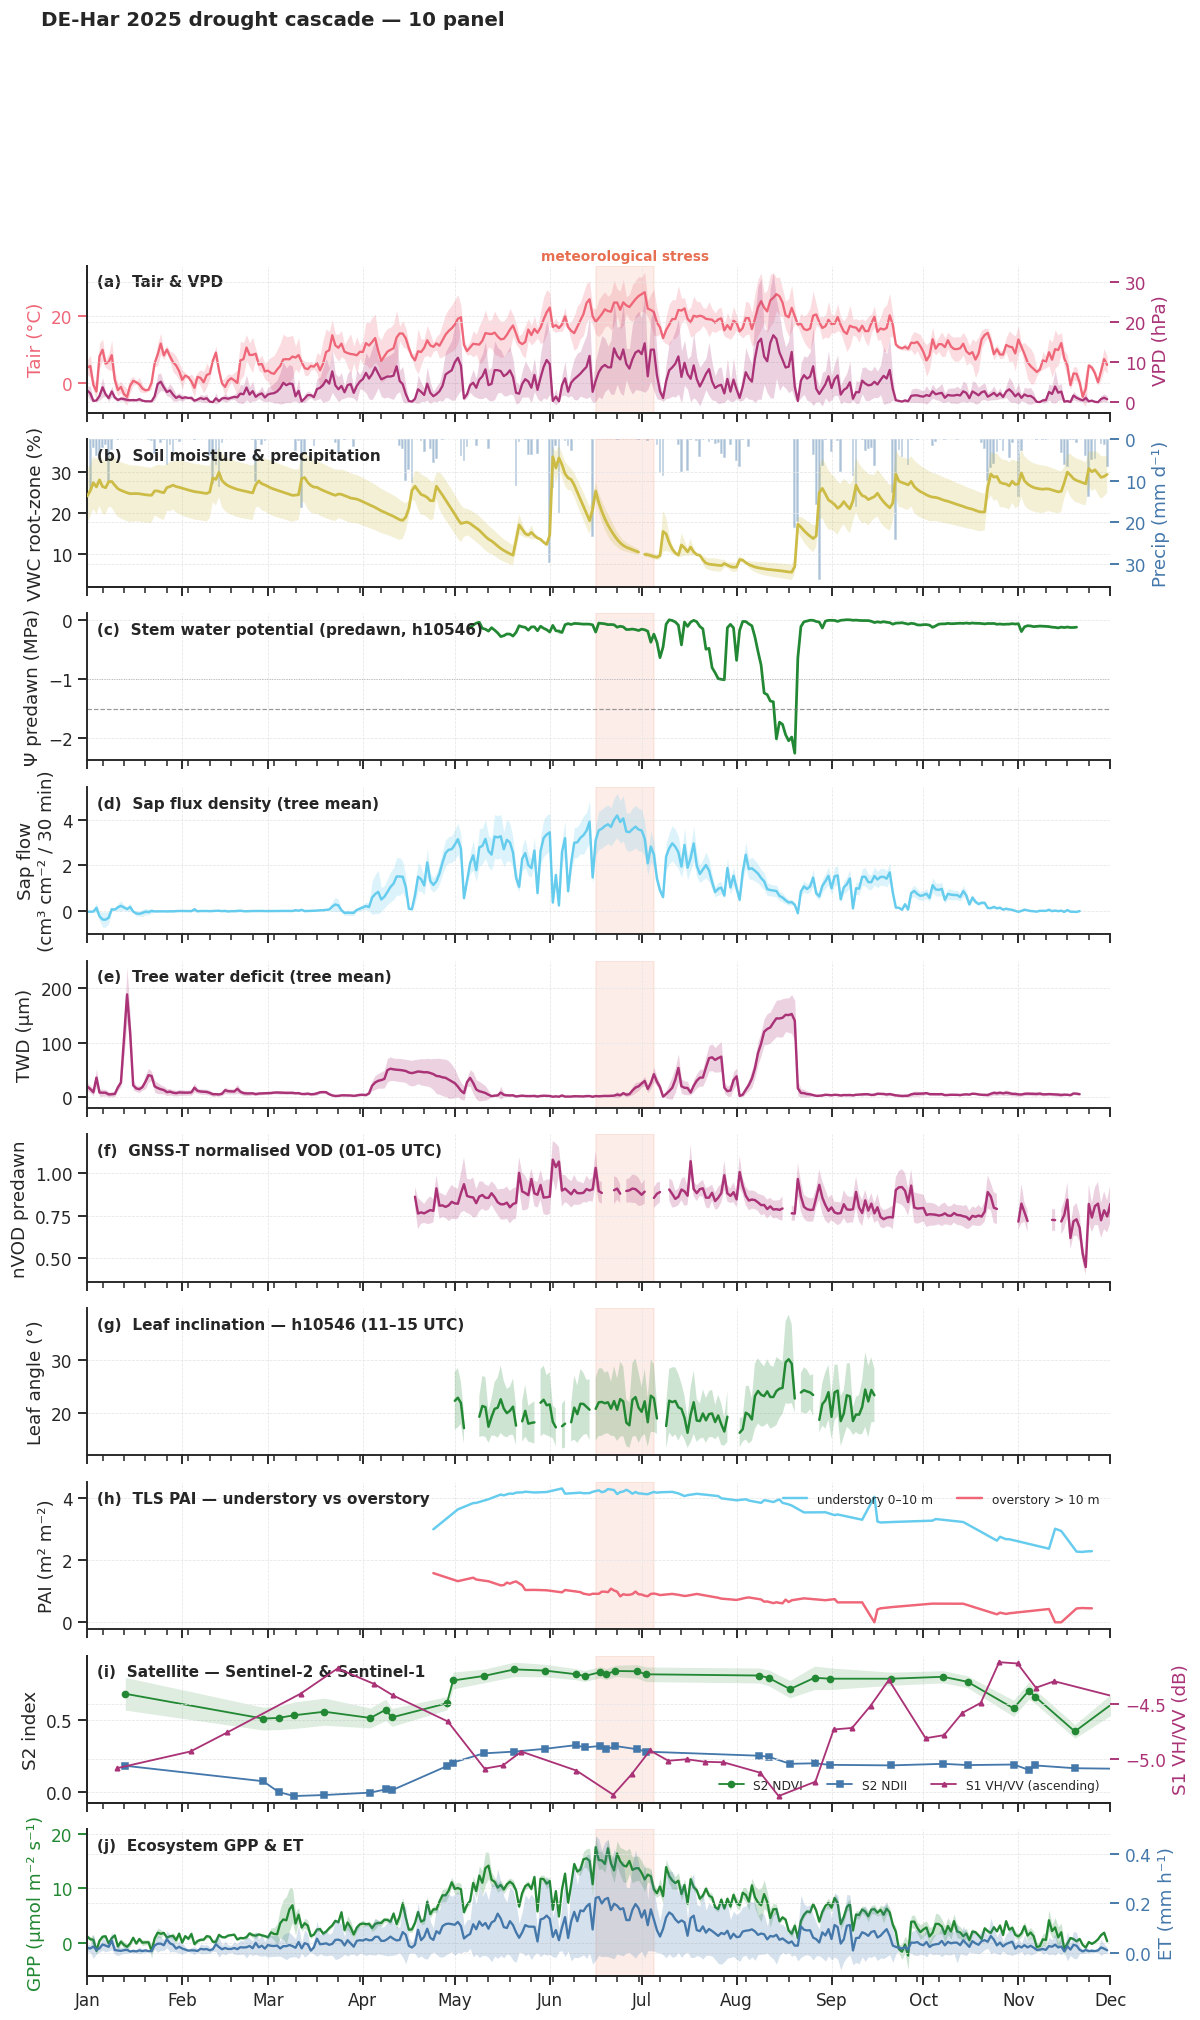

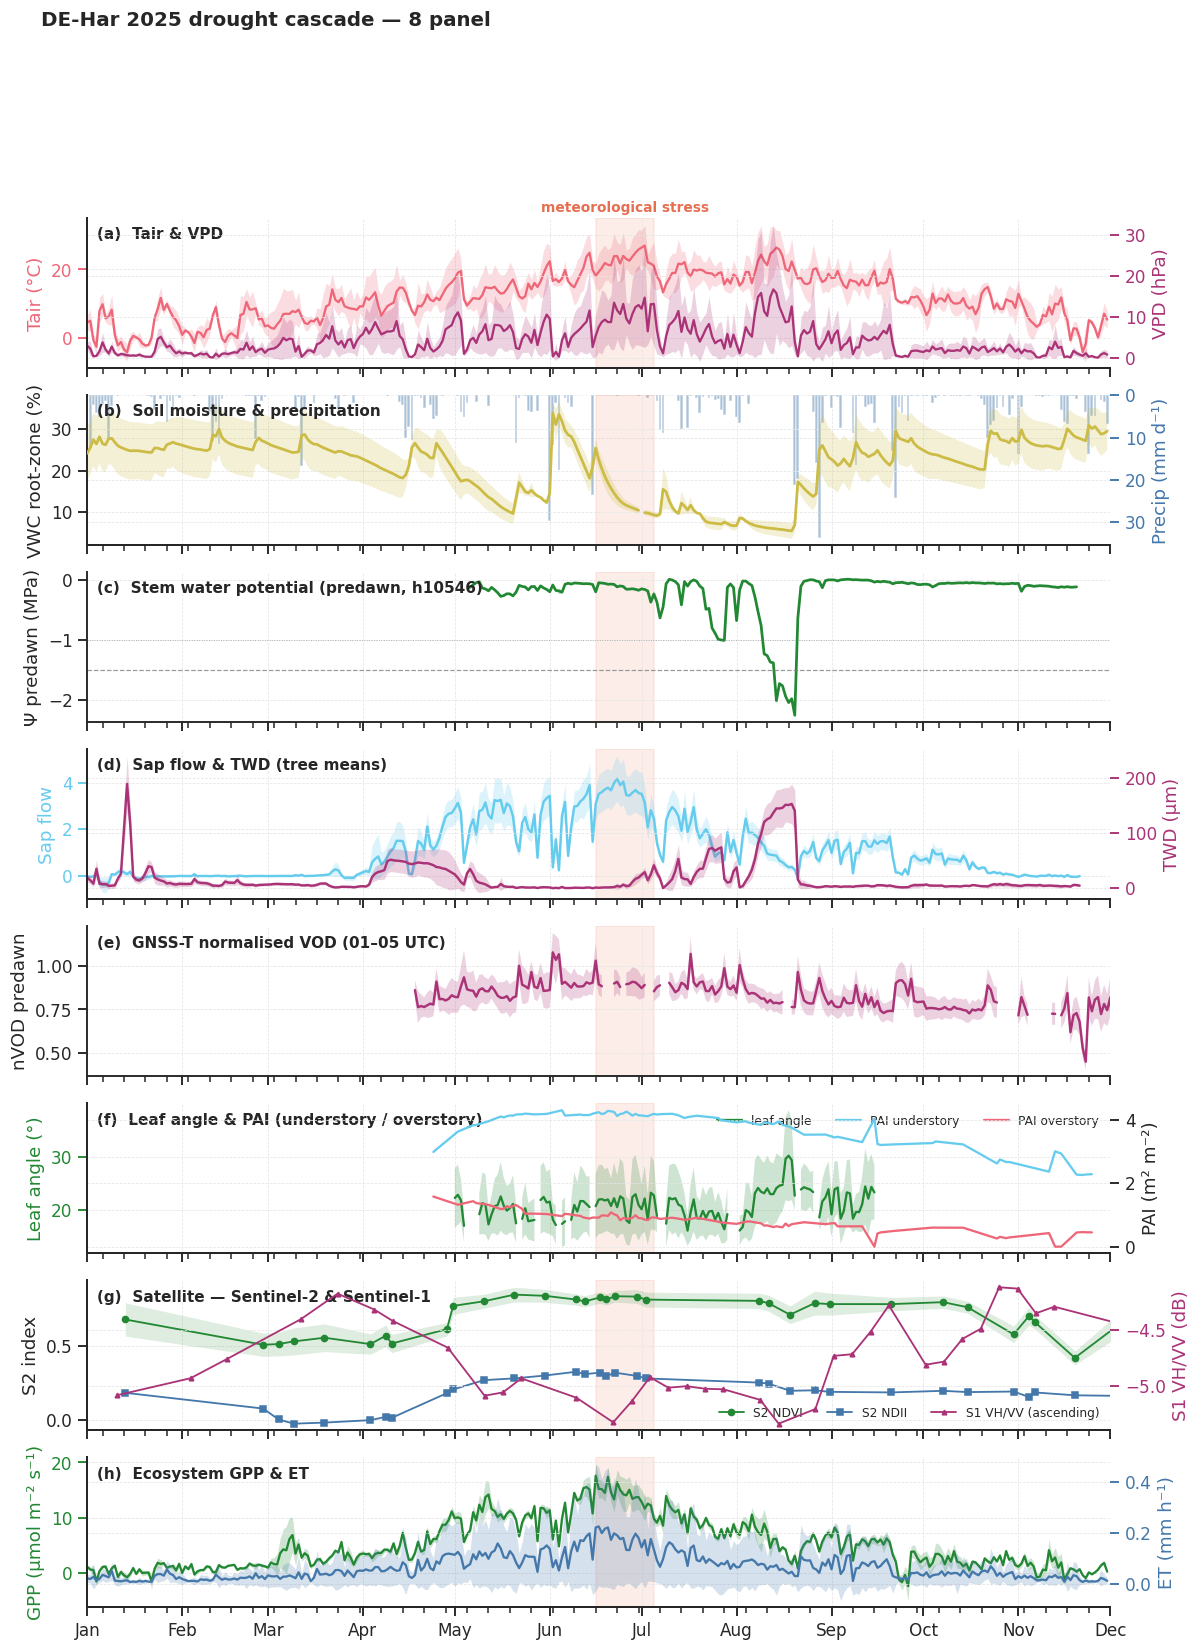

In [7]:
def _band(ax, x, y_mean, y_err, color, alpha=0.22):
    # Build aligned 1-D numpy arrays; tolerate NaN, missing y_err, mismatched indices
    ym = pd.Series(y_mean) if not isinstance(y_mean, pd.Series) else y_mean
    ye = pd.Series(y_err)  if not isinstance(y_err,  pd.Series) else y_err
    ym, ye = ym.align(ye, join="left")
    ye = ye.fillna(0.0)
    x_used = ym.index
    vals_m = ym.to_numpy(dtype=float)
    vals_e = ye.to_numpy(dtype=float)
    lo = vals_m - vals_e
    hi = vals_m + vals_e
    finite = np.isfinite(lo) & np.isfinite(hi) & np.isfinite(vals_m)
    if finite.any():
        ax.fill_between(x_used, lo, hi, where=finite, color=color, alpha=alpha, linewidth=0)

def _shade_stress(ax, met_stress):
    if met_stress[0] is not None:
        ax.axvspan(met_stress[0], met_stress[1],
                   color=STRESS_SHADE_COLOR, alpha=0.12, zorder=0)

def _label(ax, letter, title, y=0.94):
    ax.text(0.01, y, f"({letter})  {title}", transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top")

def plot_figure1(layout="10panel", out_path=None):
    # layout: '10panel' or '8panel'.
    if layout == "10panel":
        panel_specs = [("tair_vpd",), ("sm_precip",), ("swp",), ("sapflow",),
                       ("twd",), ("vod",), ("leaf_angle",), ("pai",),
                       ("satellite",), ("gpp_et",)]
    elif layout == "8panel":
        # Collapse sapflow+TWD into one twinx physiology panel; satellite+GPP/ET stacked
        panel_specs = [("tair_vpd",), ("sm_precip",), ("swp",),
                       ("sapflow_twd",), ("vod",), ("leaf_angle_pai",),
                       ("satellite",), ("gpp_et",)]
    else:
        raise ValueError(layout)

    n = len(panel_specs)
    fig, axes = plt.subplots(n, 1, figsize=(12, 1.9 * n + 1.2), sharex=True,
                             gridspec_kw={"hspace": 0.18})
    letters = "abcdefghijkl"

    x0 = pd.Timestamp("2025-01-01", tz="UTC")
    x1 = pd.Timestamp("2025-12-01", tz="UTC")

    for i, spec in enumerate(panel_specs):
        ax = axes[i]
        key = spec[0]
        _shade_stress(ax, met_stress)

        if key == "tair_vpd":
            ax2 = ax.twinx()
            ax.plot(daily["tair_mean"].index, daily["tair_mean"].values,
                    color=TOL_BRIGHT["red"], lw=1.5, label=r"$T_\mathrm{air}$ mean")
            _band(ax, daily["tair_mean"].index, daily["tair_mean"], daily["tair_std"],
                  TOL_BRIGHT["red"])
            ax2.plot(daily["vpd_mean"].index, daily["vpd_mean"].values,
                     color=TOL_BRIGHT["purple"], lw=1.5, ls="-", label="VPD mean")
            _band(ax2, daily["vpd_mean"].index, daily["vpd_mean"], daily["vpd_std"],
                  TOL_BRIGHT["purple"])
            ax.set_ylabel("Tair (°C)", color=TOL_BRIGHT["red"])
            ax2.set_ylabel("VPD (hPa)", color=TOL_BRIGHT["purple"])
            ax.tick_params(axis="y", colors=TOL_BRIGHT["red"])
            ax2.tick_params(axis="y", colors=TOL_BRIGHT["purple"])
            ax2.spines["right"].set_visible(True); ax2.spines["top"].set_visible(False)
            _label(ax, letters[i], "Tair & VPD")

        elif key == "sm_precip":
            ax2 = ax.twinx()
            ax2.bar(daily["precip_mm"].index, daily["precip_mm"].values,
                    color=TOL_BRIGHT["blue"], alpha=0.45, width=0.9, zorder=1)
            ax2.invert_yaxis()
            ax2.set_ylabel("Precip (mm d⁻¹)", color=TOL_BRIGHT["blue"])
            ax2.tick_params(axis="y", colors=TOL_BRIGHT["blue"])
            ax2.spines["right"].set_visible(True); ax2.spines["top"].set_visible(False)
            ax.plot(daily["sm_mean"].index, daily["sm_mean"].values,
                    color=TOL_BRIGHT["yellow"], lw=1.8, zorder=3)
            _band(ax, daily["sm_mean"].index, daily["sm_mean"], daily["sm_std"],
                  TOL_BRIGHT["yellow"])
            ax.set_ylabel("VWC root-zone (%)")
            ax.set_zorder(ax2.get_zorder() + 1)
            ax.patch.set_visible(False)
            _label(ax, letters[i], "Soil moisture & precipitation")

        elif key == "swp":
            ax.plot(daily["swp_pd"].index, daily["swp_pd"].values,
                    color=TOL_BRIGHT["green"], lw=1.8)
            _band(ax, daily["swp_pd"].index, daily["swp_pd"], daily["swp_pd_ci95"],
                  TOL_BRIGHT["green"])
            ax.axhline(SWP_STRESS_MPA, color="grey", ls="--", lw=0.8, alpha=0.8)
            ax.axhline(-1.0, color="grey", ls=":", lw=0.6, alpha=0.6)
            ax.set_ylabel("Ψ predawn (MPa)")
            _label(ax, letters[i], f"Stem water potential (predawn, {SWP_TREE})")

        elif key == "sapflow":
            ax.plot(daily["sapflow_mean"].index, daily["sapflow_mean"].values,
                    color=TOL_BRIGHT["cyan"], lw=1.6)
            _band(ax, daily["sapflow_mean"].index, daily["sapflow_mean"],
                  daily["sapflow_std"], TOL_BRIGHT["cyan"])
            ax.set_ylabel("Sap flow\n(cm³ cm⁻² / 30 min)")
            _label(ax, letters[i], "Sap flux density (tree mean)")

        elif key == "twd":
            ax.plot(daily["twd_mean"].index, daily["twd_mean"].values,
                    color=TOL_BRIGHT["purple"], lw=1.6)
            _band(ax, daily["twd_mean"].index, daily["twd_mean"],
                  daily["twd_std"], TOL_BRIGHT["purple"])
            ax.set_ylabel("TWD (µm)")
            _label(ax, letters[i], "Tree water deficit (tree mean)")

        elif key == "sapflow_twd":     # 8-panel combined
            ax2 = ax.twinx()
            ax.plot(daily["sapflow_mean"].index, daily["sapflow_mean"].values,
                    color=TOL_BRIGHT["cyan"], lw=1.6, label="sap flow")
            _band(ax, daily["sapflow_mean"].index, daily["sapflow_mean"],
                  daily["sapflow_std"], TOL_BRIGHT["cyan"])
            ax2.plot(daily["twd_mean"].index, daily["twd_mean"].values,
                     color=TOL_BRIGHT["purple"], lw=1.6, label="TWD")
            _band(ax2, daily["twd_mean"].index, daily["twd_mean"],
                  daily["twd_std"], TOL_BRIGHT["purple"])
            ax.set_ylabel("Sap flow", color=TOL_BRIGHT["cyan"])
            ax2.set_ylabel("TWD (µm)", color=TOL_BRIGHT["purple"])
            ax.tick_params(axis="y", colors=TOL_BRIGHT["cyan"])
            ax2.tick_params(axis="y", colors=TOL_BRIGHT["purple"])
            ax2.spines["right"].set_visible(True); ax2.spines["top"].set_visible(False)
            _label(ax, letters[i], "Sap flow & TWD (tree means)")

        elif key == "vod":
            ax.plot(daily["vod_pd_mean"].index, daily["vod_pd_mean"].values,
                    color=TOL_BRIGHT["purple"], lw=1.6)
            _band(ax, daily["vod_pd_mean"].index, daily["vod_pd_mean"],
                  daily["vod_pd_std"], TOL_BRIGHT["purple"])
            ax.set_ylabel("nVOD predawn")
            _label(ax, letters[i], "GNSS-T normalised VOD (01–05 UTC)")

        elif key == "leaf_angle":
            ax.plot(daily["leaf_angle_mean"].index, daily["leaf_angle_mean"].values,
                    color=TOL_BRIGHT["green"], lw=1.6)
            _band(ax, daily["leaf_angle_mean"].index, daily["leaf_angle_mean"],
                  daily["leaf_angle_std"], TOL_BRIGHT["green"])
            ax.set_ylabel("Leaf angle (°)")
            _label(ax, letters[i], f"Leaf inclination — {SWP_TREE} (11–15 UTC)")

        elif key == "pai":
            ax.plot(daily["pai_understory"].index, daily["pai_understory"].values,
                    color=TOL_BRIGHT["cyan"], lw=1.6, label="understory 0–10 m")
            _band(ax, daily["pai_understory"].index, daily["pai_understory"],
                  daily["pai_understory_std"], TOL_BRIGHT["cyan"])
            ax.plot(daily["pai_overstory"].index, daily["pai_overstory"].values,
                    color=TOL_BRIGHT["red"], lw=1.6, label="overstory > 10 m")
            _band(ax, daily["pai_overstory"].index, daily["pai_overstory"],
                  daily["pai_overstory_std"], TOL_BRIGHT["red"])
            ax.set_ylabel("PAI (m² m⁻²)")
            ax.legend(loc="upper right", frameon=False, fontsize=8, ncol=2)
            _label(ax, letters[i], "TLS PAI — understory vs overstory")

        elif key == "leaf_angle_pai":  # 8-panel combined
            ax2 = ax.twinx()
            ax.plot(daily["leaf_angle_mean"].index, daily["leaf_angle_mean"].values,
                    color=TOL_BRIGHT["green"], lw=1.5, label="leaf angle")
            _band(ax, daily["leaf_angle_mean"].index, daily["leaf_angle_mean"],
                  daily["leaf_angle_std"], TOL_BRIGHT["green"])
            ax2.plot(daily["pai_understory"].index, daily["pai_understory"].values,
                     color=TOL_BRIGHT["cyan"], lw=1.5, label="PAI understory")
            ax2.plot(daily["pai_overstory"].index, daily["pai_overstory"].values,
                     color=TOL_BRIGHT["red"], lw=1.5, label="PAI overstory")
            ax.set_ylabel("Leaf angle (°)", color=TOL_BRIGHT["green"])
            ax2.set_ylabel("PAI (m² m⁻²)")
            ax.tick_params(axis="y", colors=TOL_BRIGHT["green"])
            ax2.spines["right"].set_visible(True); ax2.spines["top"].set_visible(False)
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            ax.legend(h1+h2, l1+l2, loc="upper right", frameon=False, fontsize=8, ncol=3)
            _label(ax, letters[i], "Leaf angle & PAI (understory / overstory)")

        elif key == "satellite":
            ax2 = ax.twinx()
            # S2 NDVI + NDII
            if "NDVI_mean" in s2.columns:
                ax.plot(s2.index, s2["NDVI_mean"].values,
                        marker="o", ms=4, color=TOL_BRIGHT["green"], lw=1.2, label="S2 NDVI")
                _band(ax, s2.index, s2["NDVI_mean"], s2["NDVI_std"].fillna(0),
                      TOL_BRIGHT["green"], alpha=0.15)
            if "NDII_mean" in s2.columns:
                ax.plot(s2.index, s2["NDII_mean"].values,
                        marker="s", ms=4, color=TOL_BRIGHT["blue"], lw=1.2, label="S2 NDII")
            # S1 VH/VV ratio (smoothed) + RVI
            if "CR_dB_mean_smooth" in s1.columns:
                ax2.plot(s1.index, s1["CR_dB_mean_smooth"].values,
                         marker="^", ms=3, color=TOL_BRIGHT["purple"], lw=1.2,
                         label=f"S1 VH/VV ({S1_ORBIT})")
            ax.set_ylabel("S2 index")
            ax2.set_ylabel("S1 VH/VV (dB)", color=TOL_BRIGHT["purple"])
            ax2.tick_params(axis="y", colors=TOL_BRIGHT["purple"])
            ax2.spines["right"].set_visible(True); ax2.spines["top"].set_visible(False)
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            ax.legend(h1+h2, l1+l2, loc="lower right", frameon=False, fontsize=8, ncol=3)
            _label(ax, letters[i], "Satellite — Sentinel-2 & Sentinel-1")

        elif key == "gpp_et":
            ax2 = ax.twinx()
            ax.plot(daily["gpp_mean"].index, daily["gpp_mean"].values,
                    color=TOL_BRIGHT["green"], lw=1.5)
            _band(ax, daily["gpp_mean"].index, daily["gpp_mean"], daily["gpp_std"],
                  TOL_BRIGHT["green"])
            ax2.plot(daily["et_mean"].index, daily["et_mean"].values,
                     color=TOL_BRIGHT["blue"], lw=1.5)
            _band(ax2, daily["et_mean"].index, daily["et_mean"], daily["et_std"],
                  TOL_BRIGHT["blue"])
            ax.set_ylabel("GPP (µmol m⁻² s⁻¹)", color=TOL_BRIGHT["green"])
            ax2.set_ylabel("ET (mm h⁻¹)", color=TOL_BRIGHT["blue"])
            ax.tick_params(axis="y", colors=TOL_BRIGHT["green"])
            ax2.tick_params(axis="y", colors=TOL_BRIGHT["blue"])
            ax2.spines["right"].set_visible(True); ax2.spines["top"].set_visible(False)
            _label(ax, letters[i], "Ecosystem GPP & ET")

    axes[-1].set_xlim(x0, x1)
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    axes[-1].xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))

    if met_stress[0] is not None:
        mid = met_stress[0] + (met_stress[1] - met_stress[0]) / 2
        axes[0].text(mid, 1.02, "meteorological stress",
                     transform=axes[0].get_xaxis_transform(),
                     ha="center", va="bottom", fontsize=9,
                     fontweight="bold", color=STRESS_SHADE_COLOR)

    fig.suptitle(f"DE-Har 2025 drought cascade — {layout.replace('panel',' panel')}",
                 fontsize=13, y=0.995, x=0.09, ha="left", fontweight="bold")
    sns.despine(fig=fig, right=True, top=True)
    plt.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        fig.savefig(Path(out_path).with_suffix(".pdf"), bbox_inches="tight")
        print(f"Saved → {out_path}")
    return fig

fig1a = plot_figure1("10panel", out_path=FIG_DIR / "fig1a_timeseries_10panel.png")
fig1b = plot_figure1("8panel",  out_path=FIG_DIR / "fig1b_timeseries_8panel.png")
plt.show()

## 7. Changepoint detection — dual method

**Dense streams** → `ruptures.Dynp(model="rbf", n_bkps=2)` on baseline-normalised input, run at 14/21/30-day buffers; report median ± range.
**Sparse satellite streams** → first observation with `|r| ≥ 2σ` departure from the pre-event baseline; recovery = first sustained return within 1σ. Uncertainty = flanking-observation interval.

In [8]:
# Stream registry — name → (series, kind: "dense"|"sparse", domain, direction_expected)
# direction_expected is informational; actual direction is detected from data.
def _sparse_series_from_df(df, col):
    # Return a clean series indexed by acquisition timestamp for sparse (S1/S2) streams.
    if col not in df.columns: return None
    return df[col].dropna()

streams = {
    "Tair (mean)":      {"series": daily["tair_mean"],  "kind": "dense", "domain": "atmosphere"},
    "VPD (mean)":       {"series": daily["vpd_mean"],   "kind": "dense", "domain": "atmosphere"},
    "Soil moisture":    {"series": daily["sm_mean"],    "kind": "dense", "domain": "soil"},
    "SWP predawn":      {"series": daily["swp_pd"],     "kind": "dense", "domain": "physiology"},
    "Sap flow":         {"series": daily["sapflow_mean"], "kind": "dense", "domain": "physiology"},
    "TWD":              {"series": daily["twd_mean"],   "kind": "dense", "domain": "physiology"},
    "GNSS-T VOD (pd)":  {"series": daily["vod_pd_mean"], "kind": "dense", "domain": "proximal"},
    "Leaf angle":       {"series": daily["leaf_angle_mean"], "kind": "dense", "domain": "proximal"},
    "PAI understory":   {"series": daily["pai_understory"], "kind": "sparse", "domain": "proximal"},
    "PAI overstory":    {"series": daily["pai_overstory"],  "kind": "sparse", "domain": "proximal"},
    "GPP":              {"series": daily["gpp_mean"],   "kind": "dense", "domain": "flux"},
    "ET":               {"series": daily["et_mean"],    "kind": "dense", "domain": "flux"},
    "S2 NDVI":          {"series": _sparse_series_from_df(s2, "NDVI_mean"), "kind": "sparse", "domain": "satellite"},
    "S2 NDII":          {"series": _sparse_series_from_df(s2, "NDII_mean"), "kind": "sparse", "domain": "satellite"},
    "S1 VH/VV (dB)":    {"series": _sparse_series_from_df(s1, "CR_dB_mean_smooth"), "kind": "sparse", "domain": "satellite"},
    "S1 RVI":           {"series": _sparse_series_from_df(s1, "RVI_mean_smooth"), "kind": "sparse", "domain": "satellite"},
}

def _baseline_stats(series: pd.Series, stress_start, kind="dense"):
    # Mean/std over pre-event baseline window; wider for sparse streams.
    pre_days = BASELINE_DAYS_PRE_SPARSE if kind == "sparse" else BASELINE_DAYS_PRE
    min_n    = DROP_BASELINE_MIN_SPARSE if kind == "sparse" else DROP_BASELINE_MIN
    pre_start = stress_start - pd.Timedelta(days=pre_days[0])
    pre_end   = stress_start - pd.Timedelta(days=pre_days[1])
    baseline = series.loc[pre_start:pre_end].dropna()
    if len(baseline) < min_n:
        return None, None, len(baseline)
    return float(baseline.mean()), float(baseline.std(ddof=1)), len(baseline)

def _detect_dense(series: pd.Series, stress_start, stress_end, buffer_days: int):
    # Return (onset_date, recovery_date) via Dynp on baseline-z-scored window.
    z_start = stress_start - pd.Timedelta(days=buffer_days)
    z_end   = stress_end   + pd.Timedelta(days=buffer_days)
    seg = series.loc[z_start:z_end].copy()
    if len(seg.dropna()) < DROP_NOBS_MIN:
        return None, None, np.nan
    gap_frac = seg.isna().mean()
    if gap_frac > DROP_GAPFRAC_MAX:
        return None, None, gap_frac
    mean_b, std_b, n_b = _baseline_stats(series, stress_start, kind="dense")
    if mean_b is None or std_b == 0:
        return None, None, gap_frac
    y = (seg.interpolate("linear").bfill().ffill() - mean_b) / std_b
    try:
        algo = rpt.Dynp(model="rbf", min_size=5).fit(y.values)
        bkps = algo.predict(n_bkps=2)
        # bkps are segment-end indices; first internal change = bkps[0]
        onset_idx    = bkps[0]
        recovery_idx = bkps[1]
        onset_date    = seg.index[min(onset_idx,    len(seg) - 1)]
        recovery_date = seg.index[min(recovery_idx, len(seg) - 1)]
        return onset_date, recovery_date, gap_frac
    except Exception:
        return None, None, gap_frac

def detect_changepoint_dense(series, stress_start, stress_end, sweep_days=BUFFER_SWEEP_DAYS):
    # Run sensitivity sweep; return dict with median + range whisker.
    onsets, recovs = [], []
    for b in sweep_days:
        o, r, _ = _detect_dense(series, stress_start, stress_end, b)
        if o is not None: onsets.append(o)
        if r is not None: recovs.append(r)
    if not onsets:
        return None
    return {
        "onset_date": pd.Timestamp(np.array(onsets, dtype="datetime64[ns]").astype("int64").mean(), tz="UTC").floor("D"),
        "onset_lo":   min(onsets), "onset_hi": max(onsets),
        "recovery_date": pd.Timestamp(np.array(recovs, dtype="datetime64[ns]").astype("int64").mean(), tz="UTC").floor("D") if recovs else pd.NaT,
        "recovery_lo": min(recovs) if recovs else pd.NaT,
        "recovery_hi": max(recovs) if recovs else pd.NaT,
    }

def detect_changepoint_sparse(series, stress_start, stress_end, zoom_start, zoom_end):
    # First observation |r| >= sigma_thresh from baseline; recovery = first sustained return.
    seg = series.loc[zoom_start:zoom_end].dropna().sort_index()
    if len(seg) < DROP_NOBS_MIN:
        return None
    mean_b, std_b, n_b = _baseline_stats(series, stress_start, kind="sparse")
    if mean_b is None or std_b == 0:
        return None
    r = (seg - mean_b) / std_b
    # Detected direction over the stress period
    stress_slice = r.loc[stress_start:stress_end]
    if stress_slice.empty:
        stress_slice = r  # fall back to zoom window
    direction = np.sign(stress_slice.mean()) or 1.0

    def _signed_breach(val): return direction * val >= SIGMA_THRESH

    # Anchor: last baseline observation (timestamp just before zoom) — used if the
    # first zoom obs is already past threshold (no prior in-zoom non-breach exists).
    pre_days = BASELINE_DAYS_PRE_SPARSE
    pre_start = stress_start - pd.Timedelta(days=pre_days[0])
    pre_end   = stress_start - pd.Timedelta(days=pre_days[1])
    pre_obs   = series.loc[pre_start:pre_end].dropna()
    anchor_ts = pre_obs.index[-1] if len(pre_obs) else pre_end

    onset_idx = None; onset_lo = anchor_ts
    for i in range(len(r)):
        if _signed_breach(r.iloc[i]):
            onset_idx = i
            # If i > 0 and the previous zoom obs is not breaching, use that as lo;
            # otherwise fall back to the last baseline obs.
            if i > 0 and not _signed_breach(r.iloc[i - 1]):
                onset_lo = r.index[i - 1]
            break
    if onset_idx is None:
        return None
    onset_date = r.index[onset_idx]
    onset_hi   = onset_date
    # Recovery: first sustained return within SIGMA_RECOVER for >=2 consecutive obs
    recovery_date = pd.NaT; recovery_lo = pd.NaT; recovery_hi = pd.NaT
    for j in range(onset_idx + 1, len(r) - 1):
        if abs(r.iloc[j]) < SIGMA_RECOVER and abs(r.iloc[j + 1]) < SIGMA_RECOVER:
            recovery_date = r.index[j]
            recovery_lo   = r.index[j - 1] if j >= 1 else r.index[j]
            recovery_hi   = r.index[j]
            break
    direction_glyph = "↓" if direction < 0 else "↑"
    return {
        "onset_date": onset_date, "onset_lo": onset_lo, "onset_hi": onset_hi,
        "recovery_date": recovery_date, "recovery_lo": recovery_lo, "recovery_hi": recovery_hi,
        "direction": direction_glyph,
        "magnitude_sigma": float(abs(r).max()),
    }

In [9]:
records = []
for name, meta in streams.items():
    ser = meta["series"]
    if ser is None or ser.dropna().empty:
        records.append({"stream": name, "method": meta["kind"], "domain": meta["domain"],
                        "dropped_reason": "no_series"})
        continue
    if phys_stress[0] is None:
        records.append({"stream": name, "method": meta["kind"], "domain": meta["domain"],
                        "dropped_reason": "no_phys_stress_window"})
        continue
    mean_b, std_b, n_b = _baseline_stats(ser, phys_stress[0], kind=meta["kind"])
    if mean_b is None:
        records.append({"stream": name, "method": meta["kind"], "domain": meta["domain"],
                        "n_baseline": n_b, "dropped_reason": "baseline_insufficient"})
        continue
    # Observations within the zoom window
    n_in_zoom = int(ser.loc[zoom_start:zoom_end].dropna().shape[0])
    if n_in_zoom < DROP_NOBS_MIN:
        records.append({"stream": name, "method": meta["kind"], "domain": meta["domain"],
                        "n_obs": n_in_zoom, "baseline_mean": mean_b, "baseline_std": std_b,
                        "dropped_reason": f"insufficient_sampling ({n_in_zoom}<{DROP_NOBS_MIN})"})
        continue

    # Detected direction (sign of event-mean vs baseline) — for all streams
    evt = ser.loc[phys_stress[0]:phys_stress[1]].dropna()
    if len(evt):
        dir_sign = np.sign(evt.mean() - mean_b) or 1.0
    else:
        dir_sign = 1.0
    direction_glyph = "↓" if dir_sign < 0 else "↑"

    if meta["kind"] == "dense":
        res = detect_changepoint_dense(ser, phys_stress[0], phys_stress[1])
        if res is None:
            records.append({"stream": name, "method": "dynp_rbf", "domain": meta["domain"],
                            "n_obs": n_in_zoom, "baseline_mean": mean_b, "baseline_std": std_b,
                            "dropped_reason": "dynp_failed"})
            continue
        rec = {
            "stream": name, "method": "dynp_rbf", "domain": meta["domain"],
            "n_obs": n_in_zoom, "n_baseline": n_b,
            "baseline_mean": mean_b, "baseline_std": std_b,
            "direction": direction_glyph,
            "magnitude_sigma": float((evt.subtract(mean_b).abs()/std_b).max()) if len(evt) else np.nan,
            "dropped_reason": "",
        }
        rec.update(res)
    else:
        res = detect_changepoint_sparse(ser, phys_stress[0], phys_stress[1], zoom_start, zoom_end)
        if res is None:
            records.append({"stream": name, "method": "threshold_2sigma", "domain": meta["domain"],
                            "n_obs": n_in_zoom, "baseline_mean": mean_b, "baseline_std": std_b,
                            "dropped_reason": "no_threshold_crossing"})
            continue
        rec = {
            "stream": name, "method": "threshold_2sigma", "domain": meta["domain"],
            "n_obs": n_in_zoom, "n_baseline": n_b,
            "baseline_mean": mean_b, "baseline_std": std_b,
            "dropped_reason": "",
        }
        rec.update(res)

    # days relative to stress_start / stress_end
    if pd.notna(rec.get("onset_date")):
        rec["days_from_stress_onset"] = (rec["onset_date"] - phys_stress[0]).days
    if pd.notna(rec.get("recovery_date")):
        rec["days_from_stress_end"] = (rec["recovery_date"] - phys_stress[1]).days
    records.append(rec)

horizon_df = pd.DataFrame(records)
# Sort valid rows by onset-lag; keep dropped rows at the bottom
if "days_from_stress_onset" in horizon_df.columns:
    horizon_df = horizon_df.sort_values(
        ["dropped_reason","days_from_stress_onset"],
        na_position="last", ignore_index=True,
    )
horizon_df

,stream,method,domain,n_obs,n_baseline,baseline_mean,baseline_std,direction,magnitude_sigma,dropped_reason,onset_date,onset_lo,onset_hi,recovery_date,recovery_lo,recovery_hi,days_from_stress_onset,days_from_stress_end
0,PAI understory,threshold_2sigma,proximal,19,47,4.153795,0.083137,↓,8.463871,,2025-08-01 00:00:00+00:00,2025-07-27 00:00:00+00:00,2025-08-01 00:00:00+00:00,NaT,NaT,NaT,-13,NaN
1,Leaf angle,dynp_rbf,proximal,45,22,18.825576,1.797558,↑,6.327791,,2025-08-04 00:00:00+00:00,2025-07-30 00:00:00+00:00,2025-08-08 00:00:00+00:00,2025-08-19 00:00:00+00:00,2025-08-04 00:00:00+00:00,2025-08-28 00:00:00+00:00,-10,-1.0
2,ET,dynp_rbf,flux,49,24,0.089800,0.022375,↓,2.673454,,2025-08-04 00:00:00+00:00,2025-07-20 00:00:00+00:00,2025-08-15 00:00:00+00:00,2025-08-15 00:00:00+00:00,2025-08-09 00:00:00+00:00,2025-08-20 00:00:00+00:00,-10,-5.0
3,GNSS-T VOD (pd),dynp_rbf,proximal,47,24,0.892947,0.057316,↓,2.261966,,2025-08-05 00:00:00+00:00,2025-08-04 00:00:00+00:00,2025-08-08 00:00:00+00:00,2025-08-10 00:00:00+00:00,2025-08-09 00:00:00+00:00,2025-08-13 00:00:00+00:00,-9,-10.0
4,Tair (mean),dynp_rbf,atmosphere,49,24,18.423432,1.638797,↑,4.852600,,2025-08-07 00:00:00+00:00,2025-08-05 00:00:00+00:00,2025-08-09 00:00:00+00:00,2025-08-19 00:00:00+00:00,2025-08-18 00:00:00+00:00,2025-08-20 00:00:00+00:00,-7,-1.0
5,VPD (mean),dynp_rbf,atmosphere,49,24,5.576980,2.420569,↑,4.224032,,2025-08-07 00:00:00+00:00,2025-08-05 00:00:00+00:00,2025-08-09 00:00:00+00:00,2025-08-19 00:00:00+00:00,2025-08-18 00:00:00+00:00,2025-08-20 00:00:00+00:00,-7,-1.0
6,S2 NDII,threshold_2sigma,satellite,5,9,0.303239,0.016347,↓,6.942607,,2025-08-08 10:37:50.656000+00:00,2025-07-02 10:37:38.860000+00:00,2025-08-08 10:37:50.656000+00:00,NaT,NaT,NaT,-6,NaN
7,TWD,dynp_rbf,physiology,49,24,33.752003,23.888967,↑,4.970807,,2025-08-09 00:00:00+00:00,2025-08-08 00:00:00+00:00,2025-08-10 00:00:00+00:00,2025-08-20 00:00:00+00:00,2025-08-19 00:00:00+00:00,2025-08-23 00:00:00+00:00,-5,0.0
8,SWP predawn,dynp_rbf,physiology,49,24,-0.324498,0.363698,↓,5.291785,,2025-08-10 00:00:00+00:00,2025-08-09 00:00:00+00:00,2025-08-13 00:00:00+00:00,2025-08-22 00:00:00+00:00,2025-08-20 00:00:00+00:00,2025-08-24 00:00:00+00:00,-4,2.0
9,Sap flow,dynp_rbf,physiology,49,24,1.648082,0.646662,↓,2.129768,,2025-08-10 00:00:00+00:00,2025-08-09 00:00:00+00:00,2025-08-13 00:00:00+00:00,2025-08-27 00:00:00+00:00,2025-08-23 00:00:00+00:00,2025-08-30 00:00:00+00:00,-4,7.0


## 8. Figure 2 — response-horizon (zoom + Gantt)

Saved → /mnt/data/lk1167/projects/dehar-spac/figures/poster/fig2_horizon.png


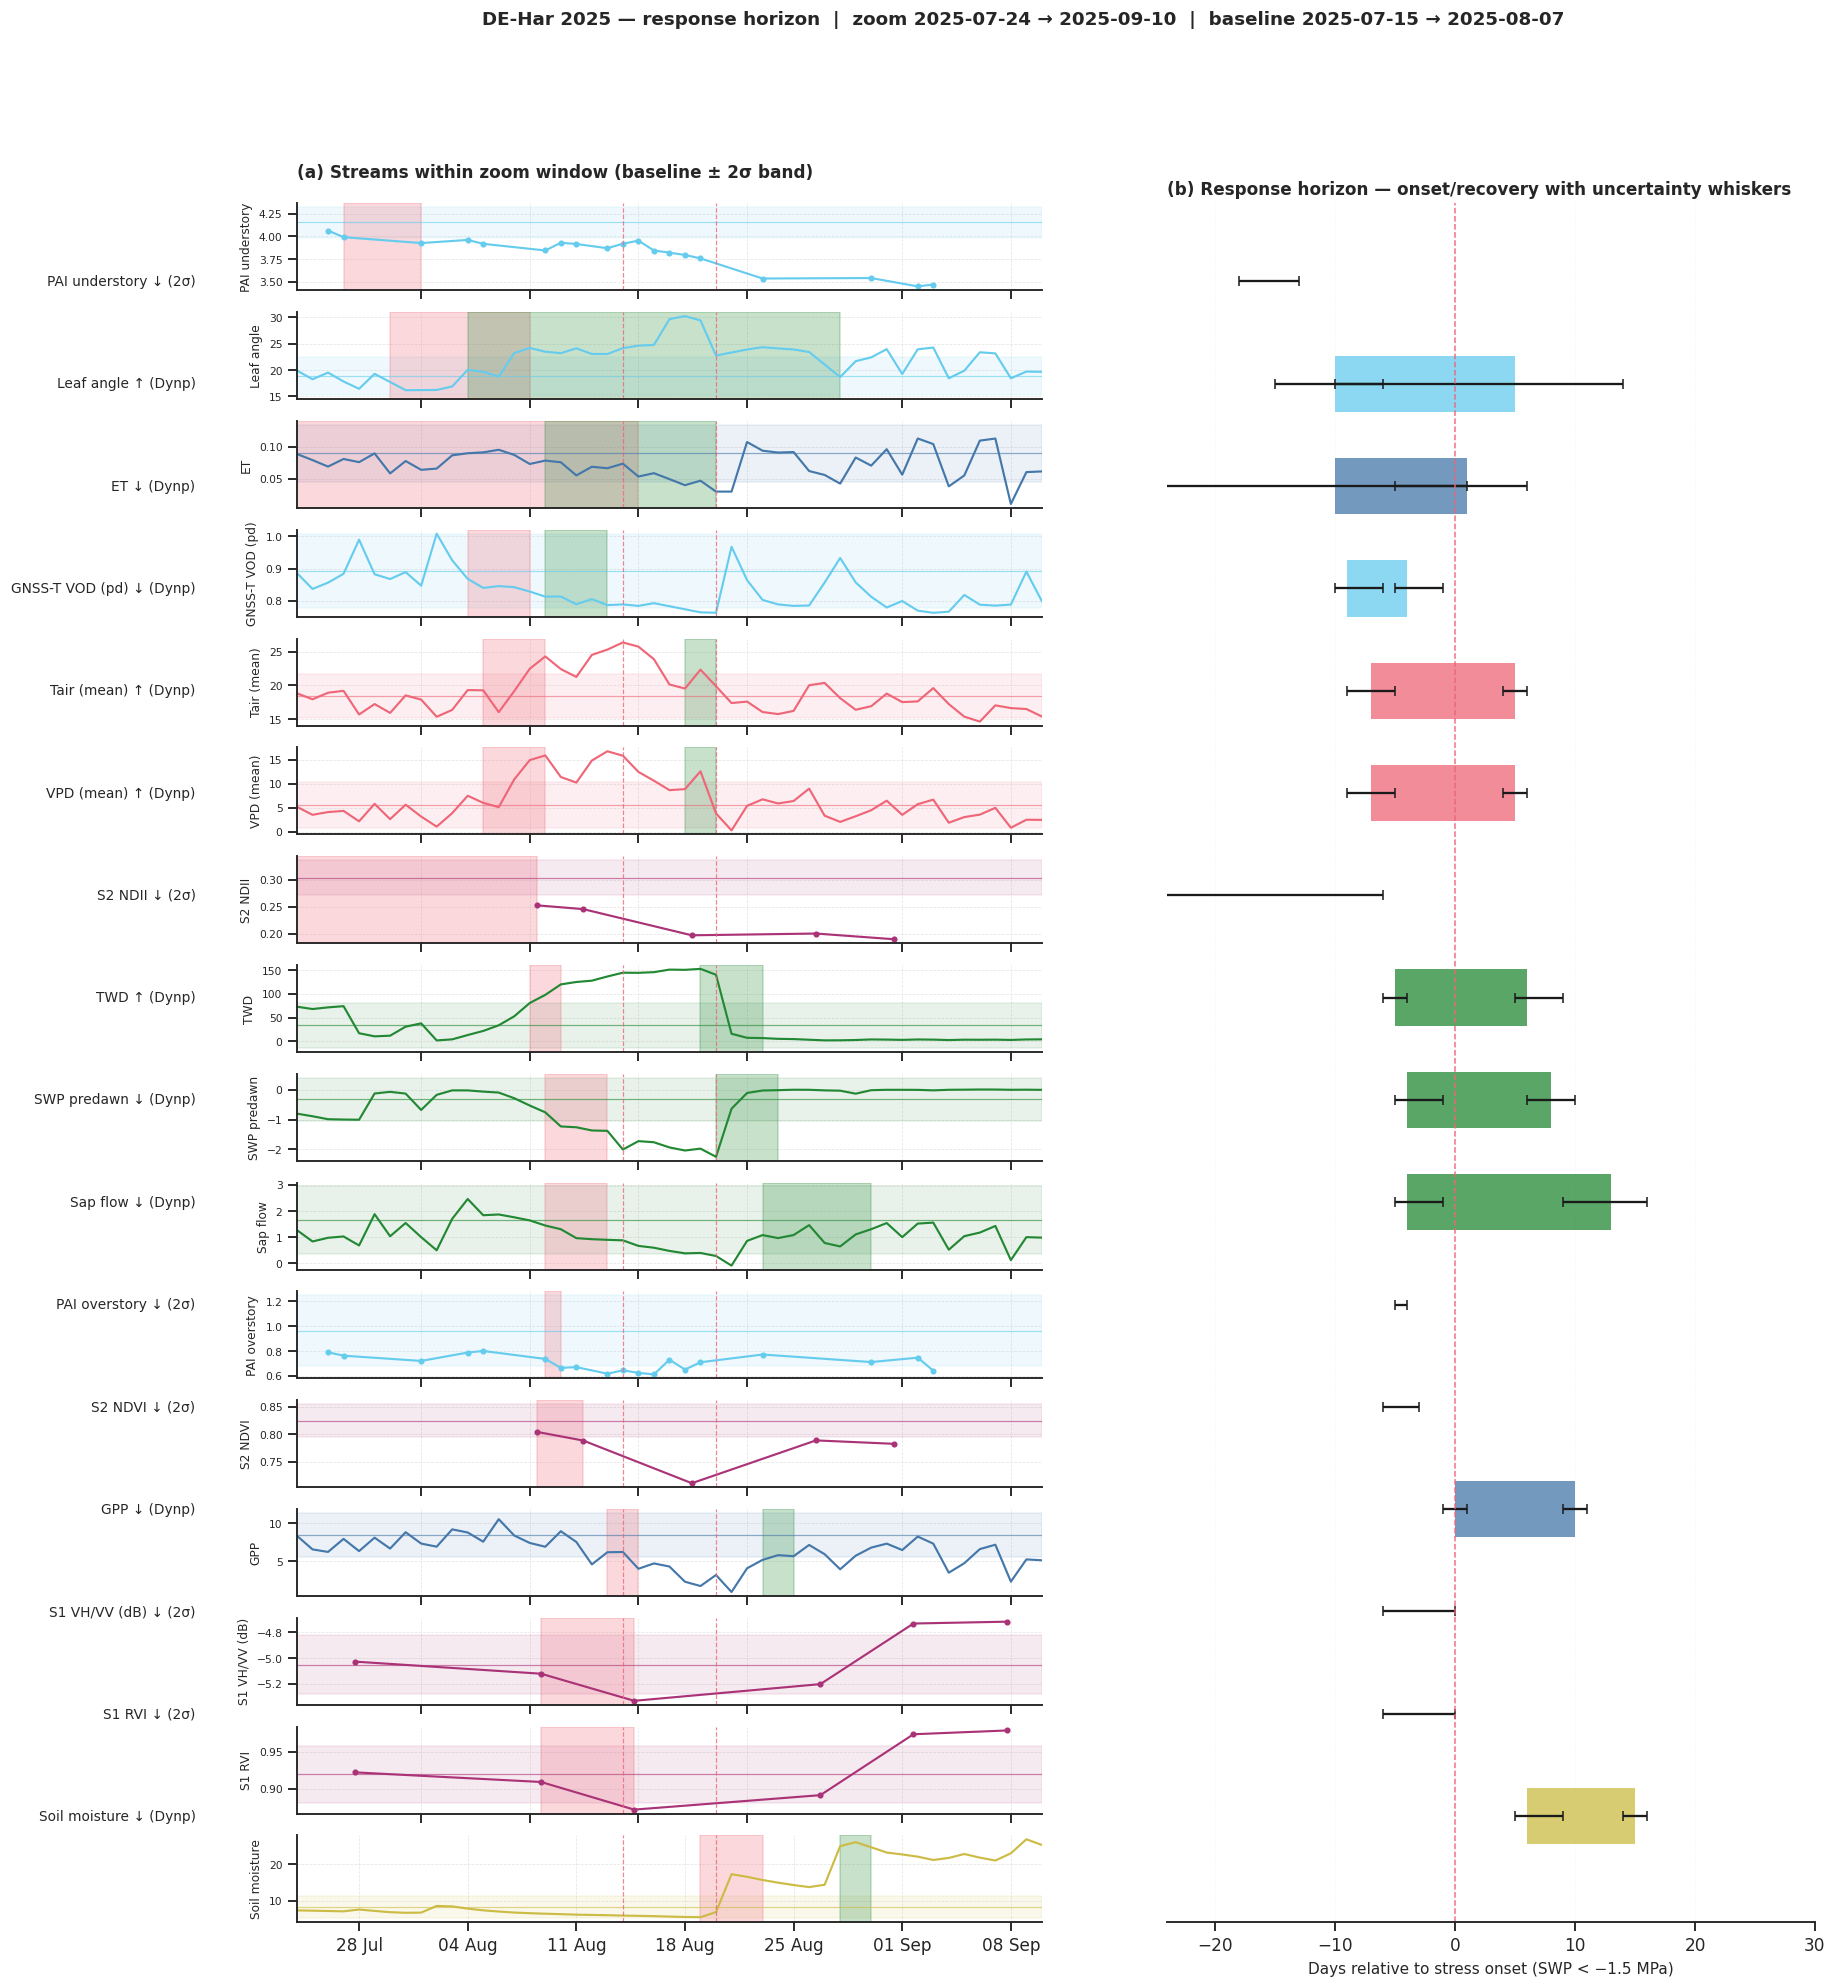

In [10]:
def plot_figure2(out_path=None):
    valid = horizon_df[horizon_df["dropped_reason"] == ""].copy()
    dropped = horizon_df[horizon_df["dropped_reason"] != ""].copy()
    if valid.empty:
        print("No valid changepoints to plot.")
        return None

    valid = valid.sort_values("days_from_stress_onset", ignore_index=True)

    # ── Figure with two panels: (a) small-multiples, (b) Gantt ──────────────
    n_streams = len(valid)
    n_ax_a = n_streams
    fig = plt.figure(figsize=(15, 1.0 + 0.85 * n_ax_a + 4.5),
                     constrained_layout=False)
    gs = fig.add_gridspec(n_ax_a + 1, 2, width_ratios=[1.15, 1],
                          hspace=0.25, wspace=0.18,
                          left=0.06, right=0.98, top=0.95, bottom=0.08)

    # (a) small-multiples on left
    ax_title_a = fig.add_subplot(gs[0, 0]); ax_title_a.axis("off")
    ax_title_a.text(0, 0, "(a) Streams within zoom window (baseline ± 2σ band)",
                    fontsize=11, fontweight="bold", va="bottom")

    ref_line_kw = dict(color=TOL_BRIGHT["red"], ls="--", lw=0.8, alpha=0.8)
    for row_i, row in valid.iterrows():
        ax = fig.add_subplot(gs[row_i + 1, 0])
        name = row["stream"]
        ser = streams[name]["series"]
        seg = ser.loc[zoom_start:zoom_end].dropna()
        baseline_mean = row["baseline_mean"]; baseline_std = row["baseline_std"]
        domain_color = DOMAIN_COLOR.get(row["domain"], TOL_BRIGHT["grey"])
        # baseline band
        ax.axhspan(baseline_mean - 2 * baseline_std, baseline_mean + 2 * baseline_std,
                   color=domain_color, alpha=0.10)
        ax.axhline(baseline_mean, color=domain_color, lw=0.8, alpha=0.6)
        ax.plot(seg.index, seg.values, "-o" if row["method"] == "threshold_2sigma" else "-",
                ms=3, color=domain_color, lw=1.4)
        # onset/recovery interval shading
        if pd.notna(row.get("onset_lo")) and pd.notna(row.get("onset_hi")):
            ax.axvspan(row["onset_lo"], row["onset_hi"], color=TOL_BRIGHT["red"], alpha=0.25)
        if pd.notna(row.get("recovery_lo")) and pd.notna(row.get("recovery_hi")):
            ax.axvspan(row["recovery_lo"], row["recovery_hi"], color=TOL_BRIGHT["green"], alpha=0.25)
        # stress reference
        ax.axvline(phys_stress[0], **ref_line_kw)
        ax.axvline(phys_stress[1], **ref_line_kw)
        ax.set_xlim(zoom_start, zoom_end)
        ax.set_ylabel(name, fontsize=8)
        ax.tick_params(axis="y", labelsize=7)
        if row_i < n_streams - 1:
            ax.tick_params(axis="x", labelbottom=False)
        else:
            ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
            for t in ax.get_xticklabels():
                t.set_rotation(0); t.set_ha("center")

    # (b) Gantt on right, same row order
    ax_b = fig.add_subplot(gs[1:, 1])
    day0 = phys_stress[0]
    def _d(t): return (pd.Timestamp(t).tz_convert("UTC") - day0).days if pd.notna(t) else np.nan

    y_pos = np.arange(len(valid))[::-1]   # top-to-bottom: earliest onset at top
    for y, (_, row) in zip(y_pos, valid.iterrows()):
        domain_color = DOMAIN_COLOR.get(row["domain"], TOL_BRIGHT["grey"])
        o, ol, oh = _d(row["onset_date"]), _d(row["onset_lo"]), _d(row["onset_hi"])
        r, rl, rh = _d(row["recovery_date"]), _d(row["recovery_lo"]), _d(row["recovery_hi"])
        # Main bar onset→recovery
        if pd.notna(o) and pd.notna(r):
            ax_b.barh(y, r - o, left=o, height=0.55, color=domain_color,
                      alpha=0.75, edgecolor="none")
        # Onset whisker
        if pd.notna(ol) and pd.notna(oh):
            ax_b.plot([ol, oh], [y, y], color="k", lw=1.5, solid_capstyle="butt")
            ax_b.plot(ol, y, "|", color="k", ms=6)
            ax_b.plot(oh, y, "|", color="k", ms=6)
        # Recovery whisker
        if pd.notna(rl) and pd.notna(rh):
            ax_b.plot([rl, rh], [y, y], color="k", lw=1.5, solid_capstyle="butt")
            ax_b.plot(rl, y, "|", color="k", ms=6)
            ax_b.plot(rh, y, "|", color="k", ms=6)
        # Method suffix
        suffix = " (Dynp)" if row["method"] == "dynp_rbf" else " (2σ)"
        direction = row.get("direction", "") or ""
        label = f"{row['stream']} {direction}{suffix}"
        ax_b.text(-1.5, y, label, va="center", ha="right", fontsize=9,
                  transform=ax_b.get_yaxis_transform())

    ax_b.axvline(0, color=TOL_BRIGHT["red"], lw=1.0, ls="--", alpha=0.9)
    ax_b.set_xlabel("Days relative to stress onset (SWP < −1.5 MPa)", fontsize=10)
    ax_b.set_yticks([])
    ax_b.set_xlim(-ZOOM_BUFFER_DAYS - 3, (phys_stress[1] - phys_stress[0]).days + ZOOM_BUFFER_DAYS + 3)
    ax_b.set_title("(b) Response horizon — onset/recovery with uncertainty whiskers",
                   fontsize=11, fontweight="bold", loc="left")
    ax_b.grid(axis="x", alpha=0.3)
    ax_b.spines["left"].set_visible(False)

    # Footnote with dropped streams
    if not dropped.empty:
        foot = "Dropped: " + "; ".join(
            f"{r['stream']} [{r.get('dropped_reason','?')}]" for _, r in dropped.iterrows()
        )
        fig.text(0.06, 0.02, foot, fontsize=8, color=TOL_BRIGHT["grey"])

    suptitle = (f"DE-Har 2025 — response horizon  |  zoom {zoom_start.date()} → {zoom_end.date()}  "
                f"|  baseline {(phys_stress[0] - pd.Timedelta(days=30)).date()} → "
                f"{(phys_stress[0] - pd.Timedelta(days=7)).date()}")
    fig.suptitle(suptitle, fontsize=12, fontweight="bold", y=0.99)

    if out_path:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        fig.savefig(Path(out_path).with_suffix(".pdf"), bbox_inches="tight")
        print(f"Saved → {out_path}")
    return fig

fig2 = plot_figure2(out_path=FIG_DIR / "fig2_horizon.png")
plt.show()

## 9. `horizon_df` — full table for the poster supplement

In [11]:
display_cols = ["stream","method","domain","n_obs","n_baseline",
                "baseline_mean","baseline_std","direction","magnitude_sigma",
                "onset_date","onset_lo","onset_hi","days_from_stress_onset",
                "recovery_date","recovery_lo","recovery_hi","days_from_stress_end",
                "dropped_reason"]
hdf = horizon_df.copy()
for c in display_cols:
    if c not in hdf.columns:
        hdf[c] = np.nan
hdf[display_cols]

,stream,method,domain,n_obs,n_baseline,baseline_mean,baseline_std,direction,magnitude_sigma,onset_date,onset_lo,onset_hi,days_from_stress_onset,recovery_date,recovery_lo,recovery_hi,days_from_stress_end,dropped_reason
0,PAI understory,threshold_2sigma,proximal,19,47,4.153795,0.083137,↓,8.463871,2025-08-01 00:00:00+00:00,2025-07-27 00:00:00+00:00,2025-08-01 00:00:00+00:00,-13,NaT,NaT,NaT,NaN,
1,Leaf angle,dynp_rbf,proximal,45,22,18.825576,1.797558,↑,6.327791,2025-08-04 00:00:00+00:00,2025-07-30 00:00:00+00:00,2025-08-08 00:00:00+00:00,-10,2025-08-19 00:00:00+00:00,2025-08-04 00:00:00+00:00,2025-08-28 00:00:00+00:00,-1.0,
2,ET,dynp_rbf,flux,49,24,0.089800,0.022375,↓,2.673454,2025-08-04 00:00:00+00:00,2025-07-20 00:00:00+00:00,2025-08-15 00:00:00+00:00,-10,2025-08-15 00:00:00+00:00,2025-08-09 00:00:00+00:00,2025-08-20 00:00:00+00:00,-5.0,
3,GNSS-T VOD (pd),dynp_rbf,proximal,47,24,0.892947,0.057316,↓,2.261966,2025-08-05 00:00:00+00:00,2025-08-04 00:00:00+00:00,2025-08-08 00:00:00+00:00,-9,2025-08-10 00:00:00+00:00,2025-08-09 00:00:00+00:00,2025-08-13 00:00:00+00:00,-10.0,
4,Tair (mean),dynp_rbf,atmosphere,49,24,18.423432,1.638797,↑,4.852600,2025-08-07 00:00:00+00:00,2025-08-05 00:00:00+00:00,2025-08-09 00:00:00+00:00,-7,2025-08-19 00:00:00+00:00,2025-08-18 00:00:00+00:00,2025-08-20 00:00:00+00:00,-1.0,
5,VPD (mean),dynp_rbf,atmosphere,49,24,5.576980,2.420569,↑,4.224032,2025-08-07 00:00:00+00:00,2025-08-05 00:00:00+00:00,2025-08-09 00:00:00+00:00,-7,2025-08-19 00:00:00+00:00,2025-08-18 00:00:00+00:00,2025-08-20 00:00:00+00:00,-1.0,
6,S2 NDII,threshold_2sigma,satellite,5,9,0.303239,0.016347,↓,6.942607,2025-08-08 10:37:50.656000+00:00,2025-07-02 10:37:38.860000+00:00,2025-08-08 10:37:50.656000+00:00,-6,NaT,NaT,NaT,NaN,
7,TWD,dynp_rbf,physiology,49,24,33.752003,23.888967,↑,4.970807,2025-08-09 00:00:00+00:00,2025-08-08 00:00:00+00:00,2025-08-10 00:00:00+00:00,-5,2025-08-20 00:00:00+00:00,2025-08-19 00:00:00+00:00,2025-08-23 00:00:00+00:00,0.0,
8,SWP predawn,dynp_rbf,physiology,49,24,-0.324498,0.363698,↓,5.291785,2025-08-10 00:00:00+00:00,2025-08-09 00:00:00+00:00,2025-08-13 00:00:00+00:00,-4,2025-08-22 00:00:00+00:00,2025-08-20 00:00:00+00:00,2025-08-24 00:00:00+00:00,2.0,
9,Sap flow,dynp_rbf,physiology,49,24,1.648082,0.646662,↓,2.129768,2025-08-10 00:00:00+00:00,2025-08-09 00:00:00+00:00,2025-08-13 00:00:00+00:00,-4,2025-08-27 00:00:00+00:00,2025-08-23 00:00:00+00:00,2025-08-30 00:00:00+00:00,7.0,
